**IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

**TASK-1 : DATA LOADING AND EXPLORATION**

In [5]:
df=pd.read_csv(r"C:\Users\ADMIN\Downloads\Housing.csv")

In [6]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [7]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 545
Columns: 13


In [12]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

**Target and Features**

In [11]:
target="price"

features=df.drop("price",axis=1)
print("Target Column:",target)
print("Feature Columns:")
print(features.columns)

Target Column: price
Feature Columns:
Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='str')


In [14]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    bool 
 13  f

In [13]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


**TASK-2 : DATA CLEANING**

In [16]:
df=df.drop_duplicates()

In [17]:
df.fillna(df.median(numeric_only=True),inplace=True)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [19]:
for col in df.select_dtypes(include=["object","string"]):
    df[col]=df[col].fillna(df[col].mode()[0])

In [20]:
df=pd.get_dummies(df,drop_first=True)

**TASK-3 : MODEL BUILDING**

In [22]:
X=df.drop("price",axis=1)
y=df["price"]

In [23]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

*Linear Regression*

In [26]:
model1=LinearRegression()
model1.fit(X_train,y_train)
y_pred_model1=model1.predict(X_test)

In [28]:
mae_model1=mean_absolute_error(y_test,y_pred_model1)
rmse_model1=np.sqrt(mean_absolute_error(y_test,y_pred_model1))
r2_model1=r2_score(y_test,y_pred_model1)
print("Linear Regression")
print("MAE: ",mae_model1)
print("RMSE: ",rmse_model1)
print("R2: ",r2_model1)

Linear Regression
MAE:  970043.403920164
RMSE:  984.9078149350648
R2:  0.6529242642153184


*Random Forest*

In [29]:
model2=RandomForestRegressor(n_estimators=100,random_state=42)
model2.fit(X_train,y_train)
y_pred_model2=model2.predict(X_test)

In [30]:
mae_model2=mean_absolute_error(y_test,y_pred_model2)
rmse_model2=np.sqrt(mean_absolute_error(y_test,y_pred_model2))
r2_model2=r2_score(y_test,y_pred_model2)
print("Random Forest")
print("MAE: ",mae_model2)
print("RMSE: ",rmse_model2)
print("R2: ",r2_model2)

Random Forest
MAE:  1021546.0353211008
RMSE:  1010.7156055592992
R2:  0.611918531405699


*MODEL COMPARISON*

In [33]:
comparison=pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[mae_model1,mae_model2],
    "RMSE":[rmse_model1,rmse_model2],
    "R2 Score":[r2_model1,r2_model2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,984.907815,0.652924
1,Random Forest,1.021546e+06,1010.715606,0.611919


**EVALUATION**

**VISUALIZATIONS**

*HISTOGRAM*

FileNotFoundError: [Errno 2] No such file or directory: 'charts/price_distribution.png'

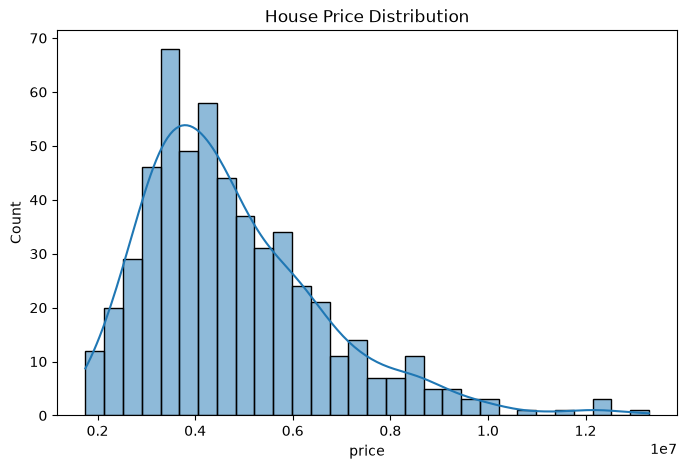

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'],bins=30,kde=True)
plt.title("House Price Distribution")
plt.savefig("charts_price_distribution.png")
plt.show()

*CORRELATION HEATMAP*

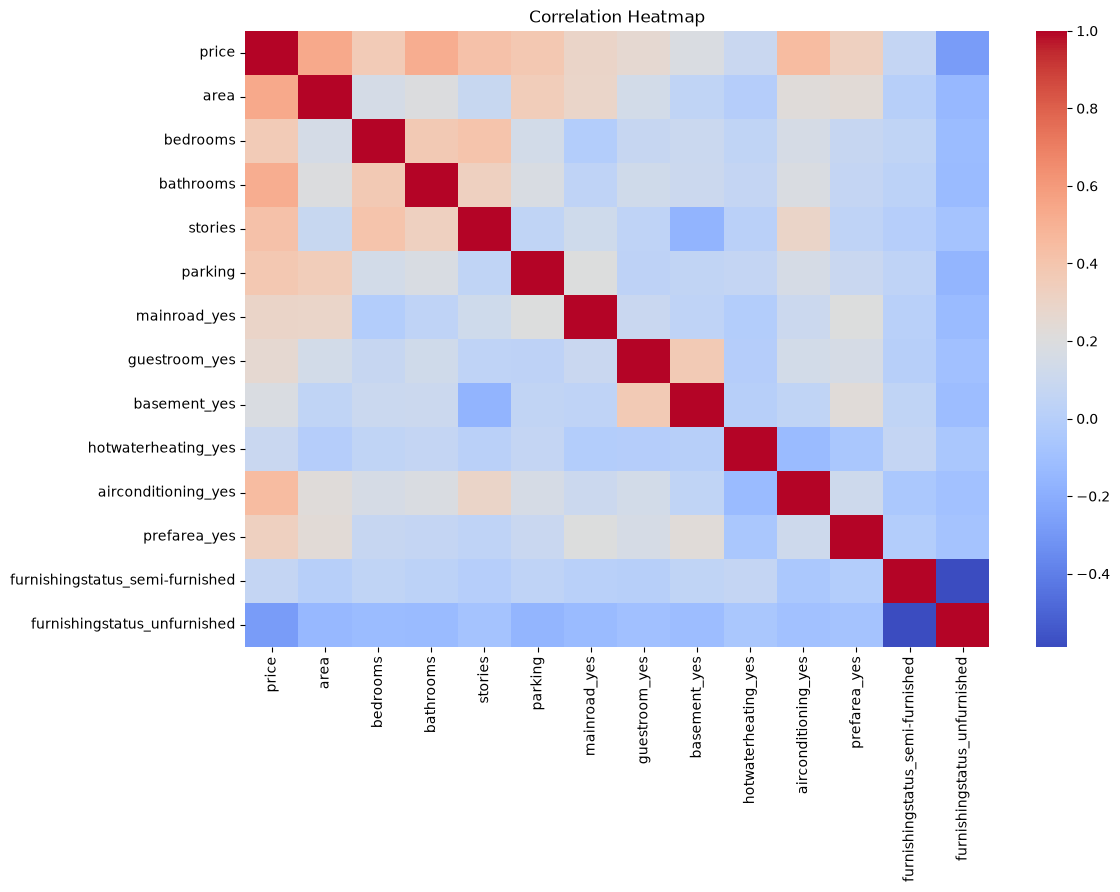

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

*ACTUAL Vs PREDICTED*

FileNotFoundError: [Errno 2] No such file or directory: 'charts/actual_vs_predicted.png'

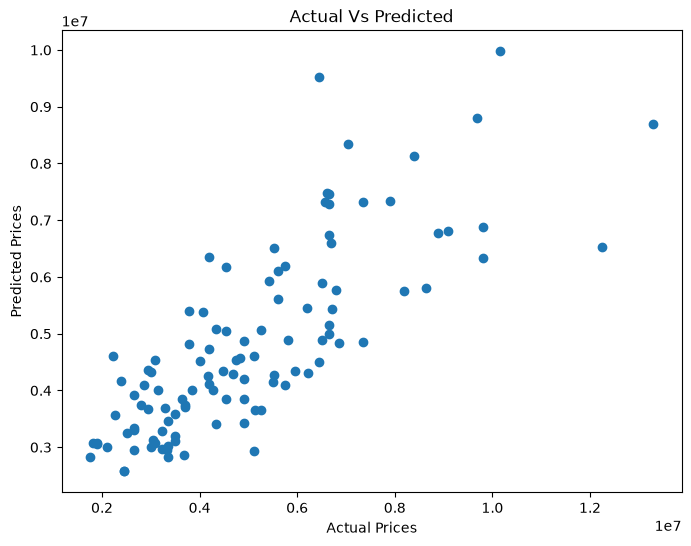

In [47]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_model2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Vs Predicted")
plt.show()

**Feature Importance**

In [38]:
imp=pd.DataFrame({
    'Feature': X.columns,
    'Importance':model2.feature_importances_
})
imp=imp.sort_values(by='Importance',ascending=False)
imp.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


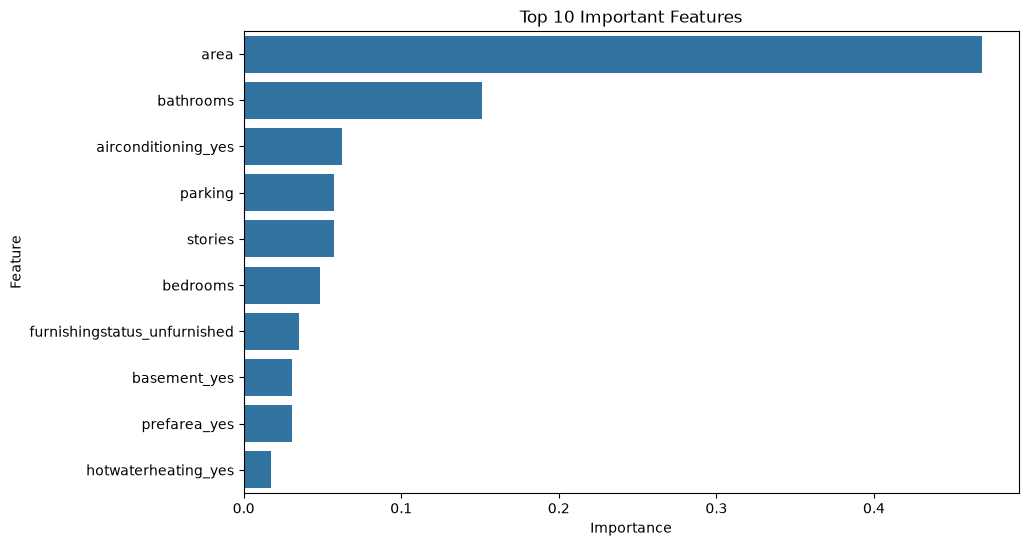

In [40]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=imp.head(10))
plt.title("Top 10 Important Features")
plt.show()

In [ ]:
**TASK-5 INSIGHTS AND SUMMARY**